In [1]:
import pandas as pd

df = pd.read_csv("Final_Sales_Pipeline.csv")
df.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,won,2016-10-25,2017-03-02,517.0


In [2]:
total_revenue = df['close_value'].sum()

In [3]:
total_deals = df.shape[0]

In [4]:
closed_won = df[df['stage'] == 'closed won'].shape[0]

KeyError: 'stage'

In [5]:
print(df.columns)


Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value'],
      dtype='object')


In [7]:
closed_won = df[df['deal_stage'] == 'closed won'].shape[0]

In [8]:
df['deal_stage'] = df['deal_stage'].str.strip().str.lower()

In [9]:
total_deals = df.shape[0]

In [10]:
closed_won = df[df['deal_stage'] == 'closed won'].shape[0]

In [12]:
conversion_rate = closed_won / total_deals

In [13]:
df['deal_stage'].value_counts()

deal_stage
won            4238
lost           2473
engaging       1589
prospecting     500
Name: count, dtype: int64

In [14]:
stage_order = ['prospecting', 'engaging', 'won', 'lost']

df['deal_stage'] = pd.Categorical(df['deal_stage'], categories=stage_order, ordered=True)

stage_counts = df['deal_stage'].value_counts().sort_index()

print(stage_counts)

deal_stage
prospecting     500
engaging       1589
won            4238
lost           2473
Name: count, dtype: int64


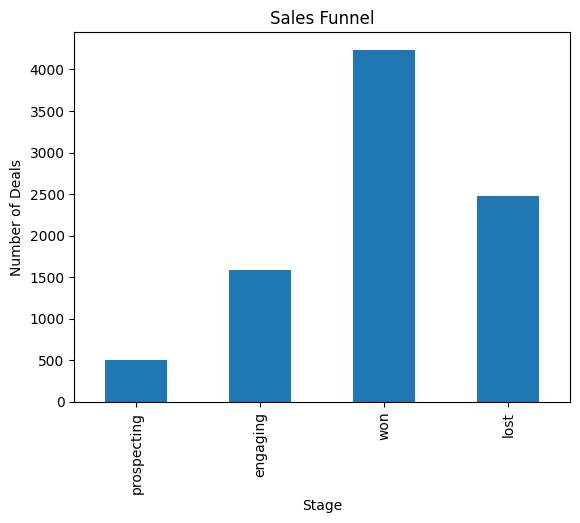

In [15]:
import matplotlib.pyplot as plt

stage_counts.plot(kind='bar')
plt.title("Sales Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Deals")
plt.show()

In [16]:
prospecting = stage_counts['prospecting']
engaging = stage_counts['engaging']

conv1 = engaging / prospecting

In [17]:
won = stage_counts['won']

conv2 = won / engaging

In [18]:
total_deals = df.shape[0]

overall_conversion = won / total_deals

In [19]:
funnel_percent = (stage_counts / stage_counts.sum()) * 100
print(funnel_percent)

deal_stage
prospecting     5.681818
engaging       18.056818
won            48.159091
lost           28.102273
Name: count, dtype: float64


In [20]:
total_revenue = df['close_value'].sum()
print(total_revenue)

10005534.0


In [21]:
df.groupby('deal_stage')['close_value'].sum()

C:\Users\Bappi\AppData\Local\Temp\ipykernel_26068\486159865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('deal_stage')['close_value'].sum()


deal_stage
prospecting           0.0
engaging              0.0
won            10005534.0
lost                  0.0
Name: close_value, dtype: float64

In [22]:
df['close_value'].mean()

1136.9925

In [23]:
df['close_date'] = pd.to_datetime(df['close_date'])

<Axes: xlabel='close_date'>

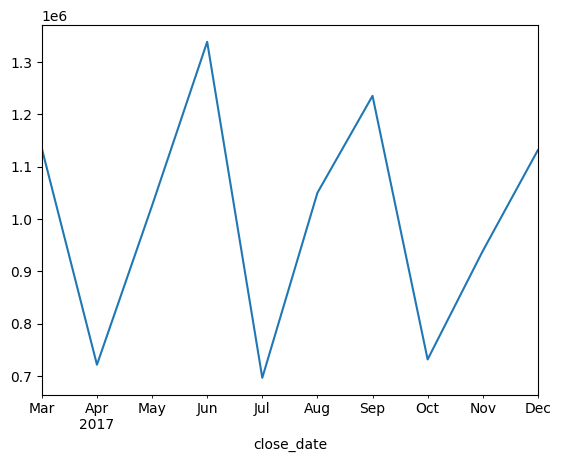

In [24]:
df.groupby(df['close_date'].dt.to_period('M'))['close_value'].sum().plot()